# EgoRecall — 05: Retrieval Ablation Study (Subset)

**Self-contained — no VM or pre-computed embeddings needed.**  
Runs on a random subset of N val clips, processing each video on-the-fly.

Compares five retrieval configurations side-by-side:

| Config | Method |
|--------|--------|
| A | CLIP image-only (baseline) |
| B | + text fusion (`object_title`, weighted α) |
| C | + query augmentation (orig / flip / padded → 3-view avg) |
| D | + text fusion + augmentation (full stack) |
| BLIP | BLIP vision encoder image-only (independent comparison) |

**Evaluation**: Recall@1, Recall@5, Recall@10, MRR — success = retrieved frame within ±5 s of response track  
**Runtime**: ~30–60 min on Colab T4 for 100 clips (parallel downloads enabled)


In [ ]:
!pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 33.7 MB/s eta 0:00:00


In [ ]:
!pip install faiss-cpu transformers torch torchvision \
    google-cloud-storage tqdm pandas pyarrow opencv-python-headless --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 89.9 MB/s eta 0:00:00


## 0 · Imports & Config

In [ ]:
import json, io, random, concurrent.futures
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image, ImageOps
from tqdm.notebook import tqdm
from google.cloud import storage
from transformers import (
    CLIPProcessor, CLIPModel,
    BlipProcessor, BlipForImageTextRetrieval,
)

# ── GCS ───────────────────────────────────────────────────────────────────
BUCKET_NAME = "egorecall-data"
GCS_CROPS   = "frames/retrieval/visual_crops/val"

# ── Local dirs ────────────────────────────────────────────────────────────
TMP_DIR     = Path("/tmp/retrieval_ablation")
RESULTS_DIR = Path("/content/results/ablation")
for d in [TMP_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Subset config ─────────────────────────────────────────────────────────
N_CLIPS          = 300  # clips to evaluate; increase for more stable metrics
RANDOM_SEED      = 114514
DOWNLOAD_WORKERS = 4    # parallel video downloads (I/O) while GPU embeds

# ── Model config ──────────────────────────────────────────────────────────
CLIP_MODEL = "openai/clip-vit-base-patch32"
BLIP_MODEL = "Salesforce/blip-itm-base-coco"
BATCH_SIZE = 64

# ── Eval config ───────────────────────────────────────────────────────────
VIDEO_FPS        = 30
INDEX_STRIDE     = 30       # 1 FPS index
TOLERANCE_SEC    = 5
TOLERANCE_FRAMES = TOLERANCE_SEC * VIDEO_FPS
K_VALUES         = [1, 5, 10]
K_MAX            = max(K_VALUES)
TEXT_ALPHA       = 0.3      # text fusion weight for configs B & D

CONFIG_NAMES = [
    "A: baseline",
    f"B: +text(α={TEXT_ALPHA})",
    "C: +aug",
    "D: +text+aug",
    "BLIP",
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Configs: {CONFIG_NAMES}")
print(f"Clips  : {N_CLIPS}  |  α = {TEXT_ALPHA}  |  K = {K_VALUES}")


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
Configs: ['A: baseline', 'B: +text(α=0.3)', 'C: +aug', 'D: +text+aug', 'BLIP']
Clips  : 300  |  α = 0.3  |  K = [1, 5, 10]


## 1 · Auth & GCS

In [ ]:
from google.colab import auth
auth.authenticate_user()
gcs_client = storage.Client()
bucket     = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")


Connected to gs://egorecall-data


## 2 · Load Annotations & Sample Subset

In [ ]:
bucket.blob("processed/vq_query_sets.parquet").download_to_filename("/tmp/vq_qs.parquet")
bucket.blob("ego4d/v2/annotations/vq_val.json").download_to_filename("/tmp/vq_val.json")

df     = pd.read_parquet("/tmp/vq_qs.parquet")
val_df = df[df["split"] == "val"].copy()

with open("/tmp/vq_val.json") as f:
    val_raw = json.load(f)

# Sample N_CLIPS random val clips
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
all_val_clips = val_df["clip_uid"].unique().tolist()
subset_clips  = set(random.sample(all_val_clips, min(N_CLIPS, len(all_val_clips))))

# Build workplan and rt_lookup from raw JSON
workplan  = {}   # clip_uid → {video_uid, v_start, v_end, qs:[...]}
rt_lookup = {}   # (annotation_uid, qs_id) → [video_frame_numbers]

for video in val_raw["videos"]:
    for clip in video["clips"]:
        cuid = clip["clip_uid"]
        if cuid not in subset_clips:
            continue
        workplan[cuid] = {
            "video_uid": video["video_uid"],
            "v_start"  : clip["video_start_frame"],
            "v_end"    : clip["video_end_frame"],
            "qs"       : [],
        }
        for anno in clip["annotations"]:
            for qs_id, qs in anno["query_sets"].items():
                if not qs.get("is_valid"):
                    continue
                aid = anno["annotation_uid"]
                workplan[cuid]["qs"].append({
                    "annotation_uid": aid,
                    "qs_id"         : qs_id,
                    "object_title"  : qs.get("object_title", "").strip().lower(),
                    "vc_blob"       : f"{GCS_CROPS}/{cuid}/{aid}_{qs_id}.jpg",
                })
                rt_lookup[(aid, qs_id)] = [
                    b["video_frame_number"] for b in qs.get("response_track", [])
                ]

n_qs = sum(len(v["qs"]) for v in workplan.values())
print(f"Sampled clips  : {len(workplan):,}")
print(f"Query-sets     : {n_qs:,}")


Sampled clips  : 300
Query-sets     : 1,157


## 3 · Load Models & Helper Functions

In [ ]:
print("Loading CLIP...")
_clip_proc  = CLIPProcessor.from_pretrained(CLIP_MODEL)
_clip_model = CLIPModel.from_pretrained(CLIP_MODEL).to(DEVICE)
_clip_model.eval()

print("Loading BLIP...")
_blip_proc  = BlipProcessor.from_pretrained(BLIP_MODEL)
_blip_model = BlipForImageTextRetrieval.from_pretrained(BLIP_MODEL).to(DEVICE)
_blip_model.eval()

print("Models loaded.")


Loading CLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

Models loaded.


In [ ]:
# ── Embedding functions ───────────────────────────────────────────────────

@torch.no_grad()
def embed_clip_images(images, batch_size=BATCH_SIZE):
    """List[PIL.Image] → L2-normalised float32 (N, 512)"""
    embs = []
    for i in range(0, len(images), batch_size):
        inp  = _clip_proc(images=images[i:i+batch_size], return_tensors="pt").to(DEVICE)
        out  = _clip_model.vision_model(pixel_values=inp["pixel_values"])
        feat = _clip_model.visual_projection(out.pooler_output)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype(np.float32)


@torch.no_grad()
def embed_clip_texts(texts, batch_size=BATCH_SIZE):
    """List[str] → L2-normalised float32 (N, 512)"""
    embs = []
    for i in range(0, len(texts), batch_size):
        inp  = _clip_proc(
            text=texts[i:i+batch_size],
            return_tensors="pt", padding=True, truncation=True,
        ).to(DEVICE)
        out  = _clip_model.text_model(
            input_ids=inp["input_ids"],
            attention_mask=inp["attention_mask"],
        )
        feat = _clip_model.text_projection(out.pooler_output)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype(np.float32)


@torch.no_grad()
def embed_blip_images(images, batch_size=BATCH_SIZE):
    """List[PIL.Image] → L2-normalised float32 (N, 768)"""
    embs = []
    for i in range(0, len(images), batch_size):
        inp  = _blip_proc(images=images[i:i+batch_size], return_tensors="pt").to(DEVICE)
        out  = _blip_model.vision_model(pixel_values=inp["pixel_values"])
        feat = out.pooler_output
        feat = feat / feat.norm(dim=-1, keepdim=True)
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype(np.float32)


def embed_augmented(images, batch_size=BATCH_SIZE):
    """3-view aug: orig + horizontal flip + padded → averaged & re-normalised."""
    n   = len(images)
    pad = lambda img: ImageOps.expand(img, border=int(max(img.size) * 0.2), fill=(128, 128, 128))
    flat = [v for img in images for v in [img, ImageOps.mirror(img), pad(img)]]
    embs  = embed_clip_images(flat, batch_size).reshape(n, 3, -1).mean(axis=1)
    norms = np.linalg.norm(embs, axis=-1, keepdims=True)
    return (embs / np.where(norms < 1e-8, 1.0, norms)).astype(np.float32)


def fuse(vis, txt, alpha):
    """Weighted fusion: normalise((1-α)·vis + α·txt)."""
    if alpha == 0:
        return vis
    out   = (1 - alpha) * vis + alpha * txt
    norms = np.linalg.norm(out, axis=-1, keepdims=True)
    return (out / np.where(norms < 1e-8, 1.0, norms)).astype(np.float32)


# ── Frame extraction ──────────────────────────────────────────────────────

def extract_frames(video_path, frame_numbers):
    """Sequential scan — fast for dense 1-FPS index frames."""
    needed = sorted(set(int(f) for f in frame_numbers))
    if not needed:
        return {}
    result, need_set = {}, set(needed)
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, needed[0])
    cur = needed[0]
    while cur <= needed[-1] and len(result) < len(needed):
        ret, frame = cap.read()
        if not ret:
            break
        if cur in need_set:
            result[cur] = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cur += 1
    cap.release()
    return result


# ── FAISS ─────────────────────────────────────────────────────────────────

def build_faiss(embs):
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs.astype(np.float32))
    return idx


# ── Metrics ───────────────────────────────────────────────────────────────

def first_hit_rank(retrieved_fns, rt_fns, tol=TOLERANCE_FRAMES):
    """1-based rank of first retrieved frame inside the ±tol window, or None."""
    if not rt_fns:
        return None
    lo, hi = min(rt_fns) - tol, max(rt_fns) + tol
    for rank, fn in enumerate(retrieved_fns, 1):
        if lo <= fn <= hi:
            return rank
    return None


def compute_metrics(rows):
    n = len(rows)
    if n == 0:
        return {f"R@{k}": 0.0 for k in K_VALUES} | {"MRR": 0.0}
    ranks = [r["rank"] for r in rows]
    out   = {f"R@{k}": sum(1 for r in ranks if r and r <= k) / n for k in K_VALUES}
    out["MRR"] = sum((1 / r if r else 0) for r in ranks) / n
    return out


print("Helpers defined.")


Helpers defined.


## 4 · Per-Clip Retrieval

For each clip:
1. Download source video (parallel, background) → extract 1-FPS index frames
2. Embed index frames with CLIP + BLIP → build two FAISS indexes
3. Download visual crops → compute 4 query embedding variants (vis / aug / txt / BLIP)
4. Fuse → run all 5 configs → record rank for each query

GPU embedding and next video download overlap via `ThreadPoolExecutor`.


In [ ]:
import pickle
from pathlib import Path

if Path("/content/checkpoint.pkl").exists():
    with open("/content/checkpoint.pkl", "rb") as f:
        checkpoint = pickle.load(f)
    all_rows = checkpoint["all_rows"]
    errors   = checkpoint["errors"]
    n_clips  = len(set(row["clip_uid"] for row in all_rows["A: baseline"]))
    print(f"Checkpoint found, {n_clips} clips included.")
else:
    all_rows = {name: [] for name in CONFIG_NAMES}
    errors   = []
    print("No Checkpoint found.")

Checkpoint found, 231 clips included.


In [ ]:
completed_clips = set(row["clip_uid"] for row in all_rows["A: baseline"])
remaining = [c for c in workplan if c not in completed_clips]
print(f" {len(completed_clips)} skipped, {len(remaining)} remaining")

def _process_one(cuid):
    vid_path = None
    try:
        info     = workplan[cuid]
        vid_path = TMP_DIR / f"{cuid}.mp4"
        if not vid_path.exists():
            bucket.blob(f"ego4d/v2/video_540ss/{info['video_uid']}.mp4") \
                  .download_to_filename(str(vid_path))

        idx_fns   = list(range(info["v_start"], info["v_end"], INDEX_STRIDE))
        frames    = extract_frames(vid_path, idx_fns)
        valid_fns = np.array(sorted(frames), dtype=np.int32)
        idx_imgs  = [frames[f] for f in valid_fns]

        vid_path.unlink(missing_ok=True); vid_path = None

        if len(idx_imgs) == 0:
            return cuid, None, "no index frames"

        idx_clip_embs = embed_clip_images(idx_imgs)
        idx_blip_embs = embed_blip_images(idx_imgs)
        k_search      = min(K_MAX, len(valid_fns))
        clip_fi       = build_faiss(idx_clip_embs)
        blip_fi       = build_faiss(idx_blip_embs)

        vc_imgs, valid_qs = [], []
        for qs in info["qs"]:
            try:
                raw = bucket.blob(qs["vc_blob"]).download_as_bytes()
                img = Image.open(io.BytesIO(raw)).convert("RGB")
                vc_imgs.append(img); valid_qs.append(qs)
            except Exception:
                pass

        if not vc_imgs:
            return cuid, None, "no visual crops"

        vis_embs  = embed_clip_images(vc_imgs)
        aug_embs  = embed_augmented(vc_imgs)
        titles    = [qs["object_title"] or "object" for qs in valid_qs]
        txt_embs  = embed_clip_texts(titles)
        blip_embs = embed_blip_images(vc_imgs)
        B_embs    = fuse(vis_embs, txt_embs, TEXT_ALPHA)
        D_embs    = fuse(aug_embs, txt_embs, TEXT_ALPHA)

        config_map = {
            "A: baseline"              : (vis_embs,  clip_fi),
            f"B: +text(α={TEXT_ALPHA})": (B_embs,    clip_fi),
            "C: +aug"                  : (aug_embs,  clip_fi),
            "D: +text+aug"             : (D_embs,    clip_fi),
            "BLIP"                     : (blip_embs, blip_fi),
        }

        rows = []
        for i, qs in enumerate(valid_qs):
            rt_fns = rt_lookup.get((qs["annotation_uid"], qs["qs_id"]), [])
            for name, (q_embs, fi) in config_map.items():
                scores, indices = fi.search(q_embs[i:i+1], k=k_search)
                retrieved = [int(valid_fns[j]) for j in indices[0] if j >= 0]
                rows.append({
                    "config"        : name,
                    "clip_uid"      : cuid,
                    "annotation_uid": qs["annotation_uid"],
                    "qs_id"         : qs["qs_id"],
                    "object_title"  : qs["object_title"],
                    "top1_score"    : float(scores[0][0]),
                    "rank"          : first_hit_rank(retrieved, rt_fns),
                })
        return cuid, rows, None

    except Exception as e:
        if vid_path is not None:
            vid_path.unlink(missing_ok=True)
        return cuid, None, str(e)


for cuid in tqdm(remaining, desc="clips", initial=len(completed_clips), total=300):
    cuid, rows, err = _process_one(cuid)
    if err:
        errors.append((cuid, err))
    elif rows:
        for row in rows:
            all_rows[row["config"]].append(row)

print(f"\nDone. Clips: {len(workplan)-len(errors):,}  Errors: {len(errors):,}")
for cid, err in errors[:5]:
    print(f"  {cid}: {err}")


 269 skipped, 31 remaining


clips:  90%|########9 | 269/300 [00:00<?, ?it/s]


Done. Clips: 297  Errors: 3
  706c54f8-2740-40bb-a341-651b708392fa: no index frames
  329a5960-3e94-44ac-aa41-f5d9bf043055: no index frames
  533e088c-b990-4280-9d9e-49ed5018c3d9: no index frames


In [ ]:
import pickle

checkpoint = {
    "all_rows": all_rows,
    "errors":   errors,
}
with open("/content/checkpoint.pkl", "wb") as f:
    pickle.dump(checkpoint, f)

n_clips = len(set(row["clip_uid"] for row in all_rows["A: baseline"]))
n_qs    = len(all_rows["A: baseline"])
print(f"Saved Clips: {n_clips}, Saved Query-sets: {n_qs}")

Saved Clips: 300, Saved Query-sets: 1157


## 5 · Results

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
summary_rows = []
for name in CONFIG_NAMES:
    rows = all_rows[name]
    m    = compute_metrics(rows)
    summary_rows.append({
        "Config" : name,
        "Queries": len(rows),
        **{k: round(v, 4) for k, v in m.items()},
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)
print(f"Subset: {len(workplan):,} val clips  |  ±{TOLERANCE_SEC}s tolerance")


         Config  Queries    R@1    R@5   R@10    MRR
    A: baseline     1157 0.0735 0.2264 0.3717 0.1435
B: +text(α=0.3)     1157 0.0743 0.2360 0.3699 0.1463
        C: +aug     1157 0.0769 0.2351 0.3708 0.1484
   D: +text+aug     1157 0.0726 0.2429 0.3751 0.1497
           BLIP     1157 0.0864 0.2766 0.4105 0.1716
Subset: 300 val clips  |  ±5s tolerance


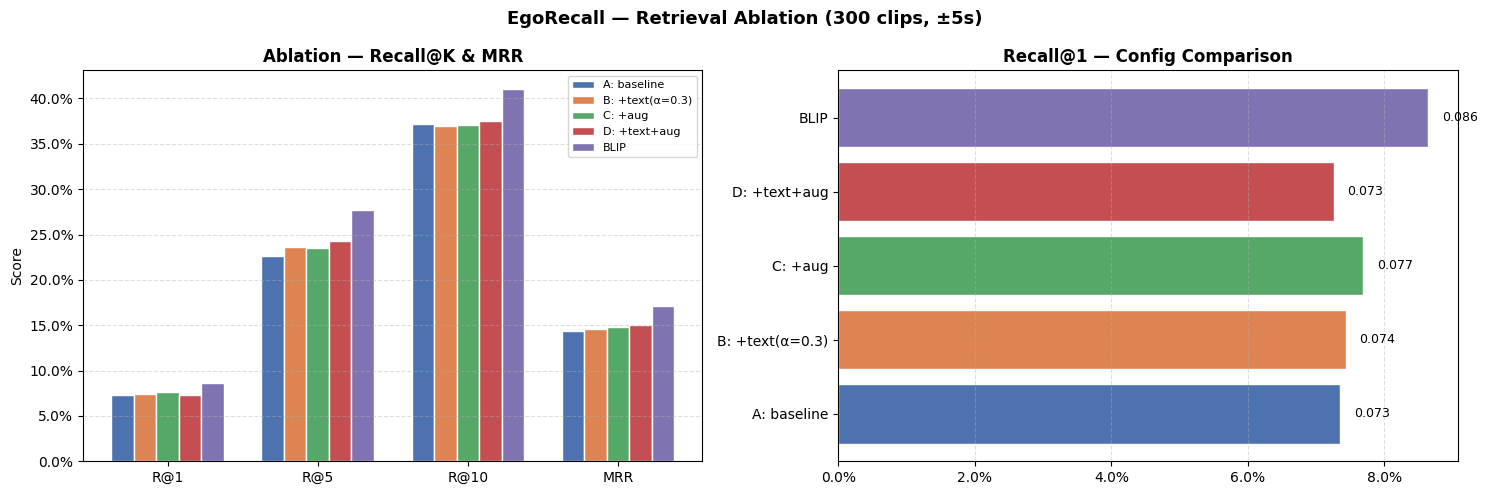

In [ ]:
# ── Ablation bar chart ────────────────────────────────────────────────────
metric_cols = [f"R@{k}" for k in K_VALUES] + ["MRR"]
palette     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
x = np.arange(len(metric_cols))
w = 0.15

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: grouped bar for all metrics
ax = axes[0]
for i, row in enumerate(summary_rows):
    ax.bar(x + i * w, [row[m] for m in metric_cols], w,
           label=row["Config"], color=palette[i], edgecolor="white")
ax.set_xticks(x + w * 2); ax.set_xticklabels(metric_cols)
ax.set_ylabel("Score")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_title("Ablation — Recall@K & MRR", fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Right: Recall@1 horizontal bar for quick scan
ax2  = axes[1]
r1   = [row["R@1"] for row in summary_rows]
bars = ax2.barh([row["Config"] for row in summary_rows], r1,
                color=palette, edgecolor="white")
for bar, val in zip(bars, r1):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax2.set_title("Recall@1 — Config Comparison", fontweight="bold")
ax2.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    f"EgoRecall — Retrieval Ablation ({len(workplan)} clips, ±{TOLERANCE_SEC}s)",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_3100/4282958545.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("area_q")["hit1"].mean()
/tmp/ipykernel_3100/4282958545.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("area_q")["hit1"].mean()


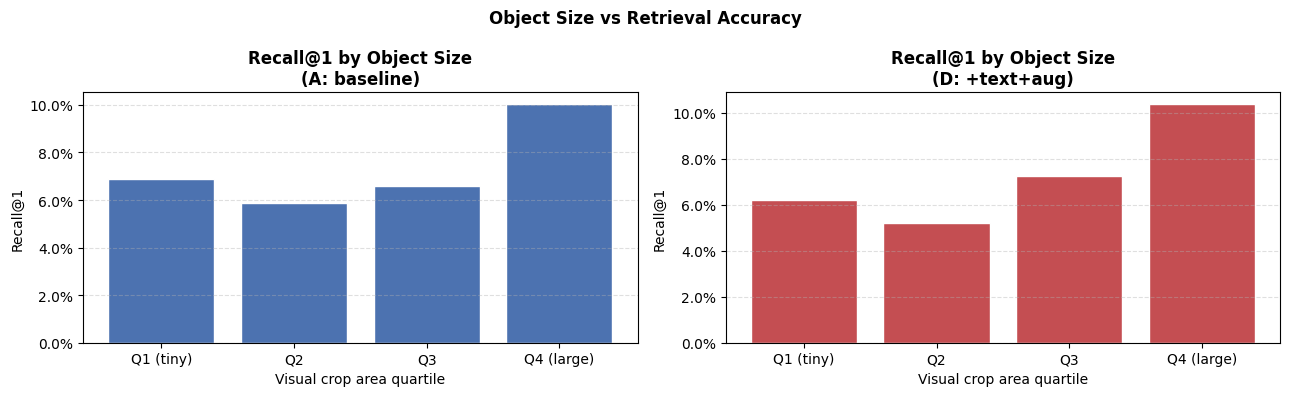

In [ ]:
# ── Per-object-title accuracy (CLIP baseline vs best) ─────────────────────
area_meta = val_df[["annotation_uid", "qs_id", "vc_area_norm"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name, color in [
    (axes[0], "A: baseline",  "#4C72B0"),
    (axes[1], "D: +text+aug", "#C44E52"),
]:
    if name not in all_rows or not all_rows[name]:
        continue
    tmp = pd.DataFrame(all_rows[name]).merge(area_meta, on=["annotation_uid","qs_id"], how="left")
    tmp["area_q"] = pd.qcut(tmp["vc_area_norm"].clip(upper=0.2), q=4,
                             labels=["Q1 (tiny)","Q2","Q3","Q4 (large)"], duplicates="drop")
    tmp["hit1"]   = tmp["rank"].apply(lambda r: 1 if r and r <= 1 else 0)
    g = tmp.groupby("area_q")["hit1"].mean()
    ax.bar(g.index, g.values, color=color, edgecolor="white")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(f"Recall@1 by Object Size\n({name})", fontweight="bold")
    ax.set_xlabel("Visual crop area quartile")
    ax.set_ylabel("Recall@1")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Object Size vs Retrieval Accuracy", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_area.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Save results ──────────────────────────────────────────────────────────
all_dfs    = [pd.DataFrame(rows) for rows in all_rows.values() if rows]
results_df = pd.concat(all_dfs, ignore_index=True)

results_df.to_parquet(RESULTS_DIR / "ablation_results.parquet", index=False)
summary_df.to_parquet(RESULTS_DIR / "ablation_summary.parquet",  index=False)

print(f"Results rows : {len(results_df):,}")
print(f"Saved to     : {RESULTS_DIR}")
print()
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

# Download to local machine
from google.colab import files
for p in [
    RESULTS_DIR / "ablation_results.parquet",
    RESULTS_DIR / "ablation_summary.parquet",
    RESULTS_DIR / "ablation_results.png",
    RESULTS_DIR / "ablation_area.png",
]:
    if p.exists():
        files.download(str(p))


Results rows : 5,785
Saved to     : /content/results/ablation

         Config  Queries    R@1    R@5   R@10    MRR
    A: baseline     1157 0.0735 0.2264 0.3717 0.1435
B: +text(α=0.3)     1157 0.0743 0.2360 0.3699 0.1463
        C: +aug     1157 0.0769 0.2351 0.3708 0.1484
   D: +text+aug     1157 0.0726 0.2429 0.3751 0.1497
           BLIP     1157 0.0864 0.2766 0.4105 0.1716


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>